<figure>
  <IMG SRC="https://raw.githubusercontent.com/mbakker7/exploratory_computing_with_python/master/tudelft_logo.png" WIDTH=250 ALIGN="right">
</figure>

# Exploratory Computing with Python using temperature and wind speed measurements collected on campus.
*Developed by Sandra Verhagen*

In this assignment we will use the temperature and wind speed measurements collected on campus during the Earth and Climate System practical.

The data is stored in a comma-separated file (.csv) provided on Brightspace. 

Learning objectives:
* demonstrate that you can use slices
* select and use functions from Matplotlib and numpy
* apply what you learned about loops, conditions, etc.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
filename = "C:\\Users\\ccalcarvan\\Documents\\AAwerk\\Teaching\\TA\\Grandchallenges2026\\CampusData.csv"

## 0. Get the data

We will use <code>np.genfromtxt</code> to read the data from the file into a Numpy array called <code>data</code>, where you will need to specify the following arguments (find out yourself what should be on the ...):
* <code>dtype=...</code> 
* <code>skip_header=...</code>
* <code>delimiter=...</code>
* <code>encoding='latin-1'</code>

(find out yourself what should be on the ...)

Note: in the remainder of this notebook we will always use the <code>data</code> array directly, so we will not create seperate arrays for each variable.

Print the shape and type of <code>data</code>.

In [10]:
data = np.genfromtxt(filename, dtype = 'float', skip_header=1, delimiter=",", encoding='latin-1')

# Print the shape of the data
print(np.shape(data))

(170, 11)


By checking the *shape* of the data we can see that it has 170 rows and 11 columns. Check the .csv file yourself to see the contents!

## 1. Create some line graphs

As a starting point, you are asked to create a plot where the numbers in the first column are the x-values, and the surface temperature (5th column) as the y-values. Don't forget to add labels and a title.

Text(0.5, 1.0, 'All surface temperature measurements')

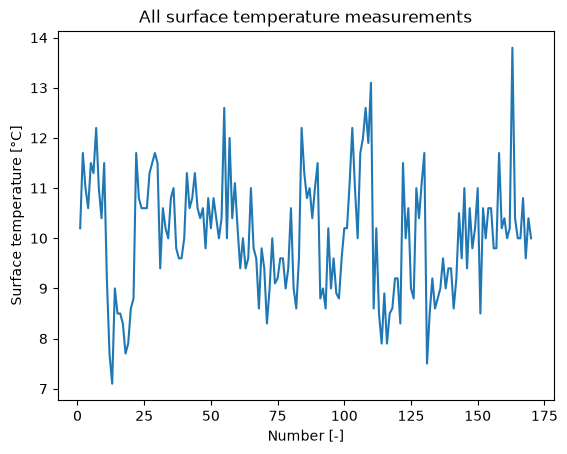

In [11]:
x = data[:,0]

plt.plot(x,data[:,4])
plt.xlabel('Number [-]')
plt.ylabel('Surface temperature [°C]')
plt.title('All surface temperature measurements')

Now create a plot, where you plot the temperatures at the three different heights in one figure, and include a legend with proper labels.

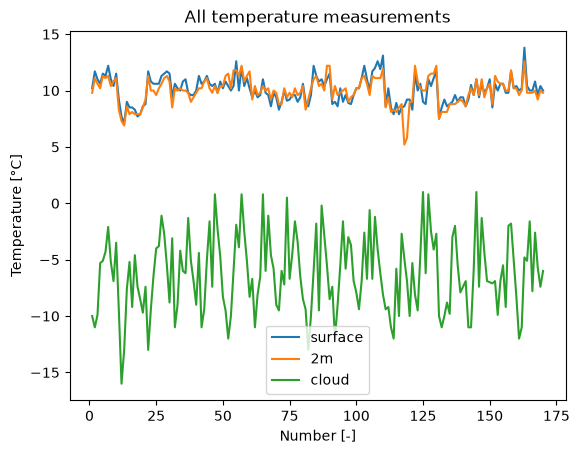

In [12]:
plt.plot(x,data[:,4],label='surface')
plt.plot(x,data[:,5],label='2m')
plt.plot(x,data[:,6],label='cloud')
plt.xlabel('Number [-]')
plt.ylabel('Temperature [°C]')
plt.title('All temperature measurements')
plt.legend();

Do the same as above, but now only plot the temperatures at the first timestamp!

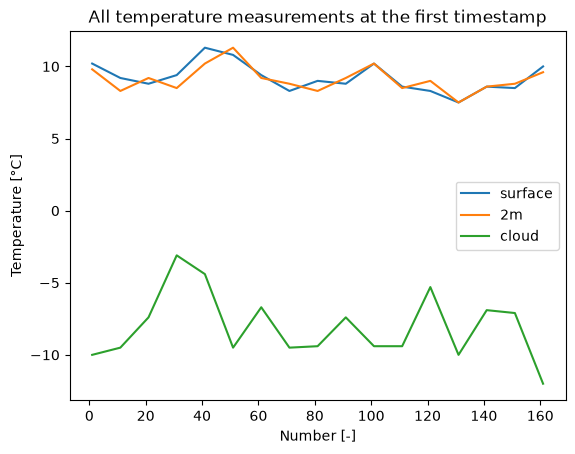

In [13]:
plt.plot(x[::10],data[::10,4],label='surface')
plt.plot(x[::10],data[::10,5],label='2m')
plt.plot(x[::10],data[::10,6],label='cloud')
plt.xlabel('Number [-]')
plt.ylabel('Temperature [°C]')
plt.title('All temperature measurements at the first timestamp')
plt.legend();

## 2. Scatterplots

From the graphs above, you can see that the temperature at the surface and at 2 meter height show a strong *correlation*: they follow a similar pattern. A scatterplot can be very useful to see whether two variables are strongly correlated or not. You will now create two *subplots*: on the left a scatterplot with surface vs. 2m temperature, and on the right with surface vs. cloud-base temperature.

We will now a slightly different way of creating the plots, labels, etc. by first creating two subplots with their own axes (here called ```ax```). For the first plot (left-side) we will now use ```ax[0].``` followed by the plot-function, and for the second (right-side) ```ax[1].```.

To add labels and title, you will now need to use for instance ```ax[0].set_xlabel('your_label')``` and ```ax[0].set_title('your_title')```

Text(0.5, 1.0, 'surface vs. cloud-base temperature')

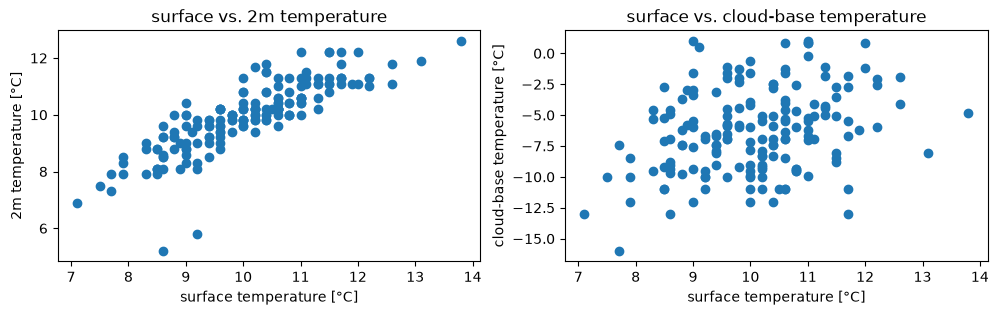

In [14]:
# this will create a figure with 2 subplots (1 row, 2 columns) with their own axes 'ax'
fig, ax = plt.subplots(1, 2, figsize=(12,3))

ax[0].scatter(data[:,4],data[:,5])
ax[0].set_xlabel('surface temperature [°C]')
ax[0].set_ylabel('2m temperature [°C]')
ax[0].set_title('surface vs. 2m temperature')

ax[1].scatter(data[:,4],data[:,6])
ax[1].set_xlabel('surface temperature [°C]')
ax[1].set_ylabel('cloud-base temperature [°C]')
ax[1].set_title('surface vs. cloud-base temperature')

## 3. Histograms

Complete the code below to produce 3 histograms for the temperatures at the different heights, where:
* <code>tempdata</code>: an array with 3 columns with the data for which to create the histograms
* <code>nbins</code>: the number of bins to be used in the histogram (should be either an integer number, or 'auto')
* <code>titles</code>: a list with the 3 titles of the subplots
* <code>colours</code>: a list with the colour for each subplot

In the code you will:
1. use <code>fig, ax = plt.subplots(...)</code> to create 3 subplots in a row with a shared y-axis (same min, max and scale);
2. use a <code>for</code>-loop to plot the three histograms using <code>histdata</code> with proper indexing, and to add the proper title and label for the x-axis;
3. add the y-axis label.

Tip: an histogram can be created for instance as follows: ```ax[0].hist(y,bins=10,color='red',alpha=0.7)```. Find out yourself what you can do with the different arguments. 


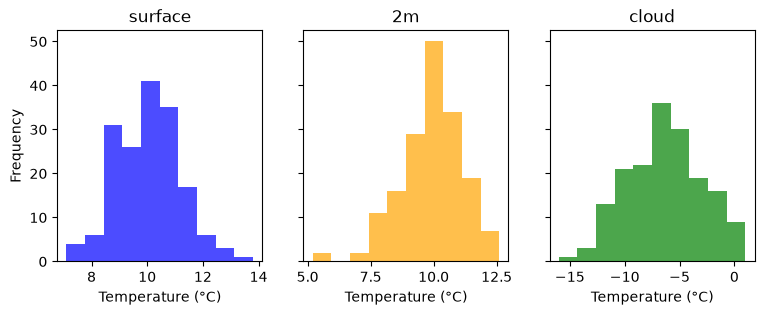

In [15]:
# select only the columns with the temperatures for all groups and times
tempdata = data[:,4:7]
nbins = 10
titles = ['surface','2m','cloud']
colours=['blue', 'orange', 'green']

# this will create a figure with 3 subplots with their own axes 'ax'
fig, ax = plt.subplots(1, 3, sharey=True, figsize=(9,3))

for i in range(3): #start loop
    # YOUR CODE HERE TO CREATE HISTOGRAM (each with its own colour)
    # AND ADD LABEL AND TITLE TO THE i-TH SUBPLOT
    ax[i].hist(tempdata[:, i], bins=nbins,color=colours[i], alpha=0.7) 
    ax[i].set_xlabel('Temperature (°C)') #set x label for each subplot
    ax[i].set_title(titles[i])

# add label to y-axis (only need to do this once, since we used sharey=True)
ax[0].set_ylabel('Frequency');

* Try with different numbers of bins!
* Try with only a subset of the observations, for instance only the first 10.

Similarly, create 4 histograms, but now divided over 2 rows and 2 columns, with the windspeeds in different directions.
Use a nested ```for```-loop, and make sure to now use shared x- and y-axes.

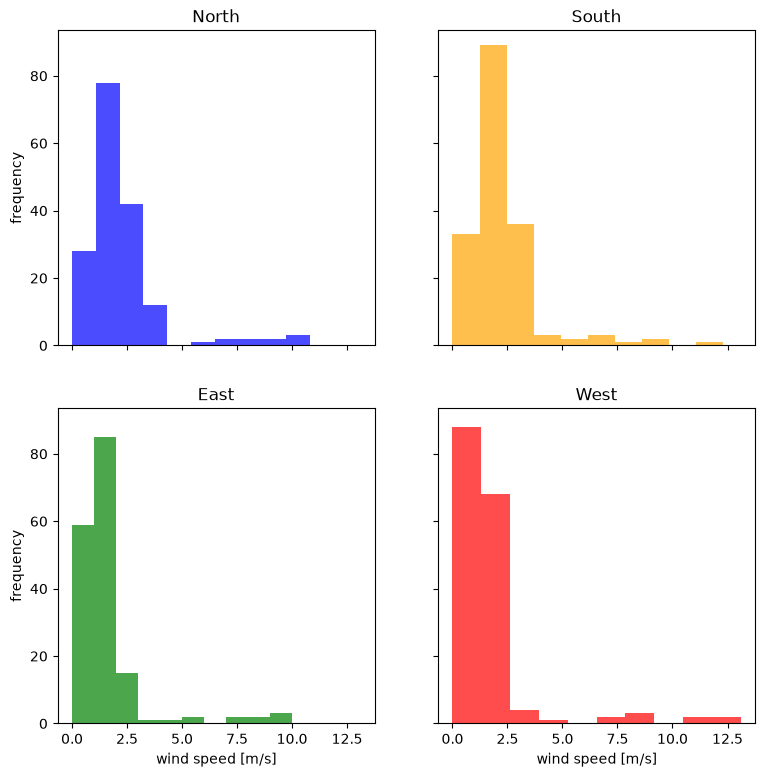

In [16]:
fig, axes = plt.subplots(2, 2, sharey=True, sharex=True, figsize=(9,9)) # figure with four subplots (2x2)

winddata = data[:,7:]
titles = ['North','South','East','West']
colour=['blue', 'orange', 'green','red'] #a list of colours for the different histograms
idx=0
for i in range(2): #start loop
    for j in range(2): #start loop
    # YOUR CODE HERE TO CREATE HISTOGRAM
    # AND ADD LABEL AND TITLE TO THE i-TH SUBPLOT
        axes[i][j].hist(winddata[:, idx], color=colour[idx], alpha=0.7) #i in range will start at 0 and go to 2; we add 3 to i to get the correct column index for temperature data 
        if i==1:  # add a logical expression to only add an x-label for the subplots at the bottom
            axes[i][j].set_xlabel('wind speed [m/s]') #set x label for each subplot at the bottom
        if j==0: # add your logical expression to only add a y-label for the subplots on the left
            axes[i][j].set_ylabel('frequency') #set y label for each subplot on the left
        axes[i][j].set_title(titles[idx])
        idx+=1

## 4. Five-number summary

We will now use some functions from Numpy to calculate the five-number summary of each measured quantity:
* minimum
* lower quartile: the 25th percentile of the quantity, meaning that 25% of the data values lie at or below this number
* median: the 50th percentile of the quantity, meaning that 50% of the data values lie at or below this number
* upper quartile: the 25th percentile of the quantity, meaning that 75% of the data values lie at or below this number
* maximum

In addition, calculate the mean of each quantity as well (and try to understand why it is different from the median).

Numpy has routines for each item, where for the quartiles you can use <code>np.percentile</code>.

Use print statements with f-strings to present the results.

In [17]:
print(f'The miminum surface temperature was: {np.min(data[:,4]):.1f}°C')
print(f'The lower quartile surface temperature was: {np.percentile(data[:,4],25):.1f}°C')
print(f'The median surface temperature was: {np.median(data[:,4]):.1f}°C')
print(f'The upper quartile surface temperature was: {np.percentile(data[:,4],75):.1f}°C')
print(f'The maximum surface temperature was: {np.max(data[:,4]):.1f}°C')

print(f'The mean surface temperature was: {np.mean(data[:,4]):.1f}°C\n')

print(f'The miminum 2m temperature was: {np.min(data[:,5]):.1f}°C')
print(f'The lower quartile 2m temperature was: {np.percentile(data[:,5],25):.1f}°C')
print(f'The median 2m temperature was: {np.median(data[:,5]):.1f}°C')
print(f'The upper quartile 2m temperature was: {np.percentile(data[:,5],75):.1f}°C')
print(f'The maximum 2m temperature was: {np.max(data[:,5]):.1f}°C')

print(f'The mean 2m temperature was: {np.mean(data[:,5]):.1f}°C\n')

print(f'The miminum cloud temperature was: {np.min(data[:,6]):.1f}°C')
print(f'The lower quartile cloud temperature was: {np.percentile(data[:,6],25):.1f}°C')
print(f'The median cloud temperature was: {np.median(data[:,6]):.1f}°C')
print(f'The upper quartile cloud temperature was: {np.percentile(data[:,6],75):.1f}°C')
print(f'The maximum cloud temperature was: {np.max(data[:,6]):.1f}°C')

print(f'The mean cloud temperature was: {np.mean(data[:,6]):.1f}°C')

The miminum surface temperature was: 7.1°C
The lower quartile surface temperature was: 9.2°C
The median surface temperature was: 10.0°C
The upper quartile surface temperature was: 10.8°C
The maximum surface temperature was: 13.8°C
The mean surface temperature was: 10.1°C

The miminum 2m temperature was: 5.2°C
The lower quartile 2m temperature was: 9.2°C
The median 2m temperature was: 10.0°C
The upper quartile 2m temperature was: 10.8°C
The maximum 2m temperature was: 12.6°C
The mean 2m temperature was: 9.9°C

The miminum cloud temperature was: -16.0°C
The lower quartile cloud temperature was: -9.0°C
The median cloud temperature was: -6.5°C
The upper quartile cloud temperature was: -4.1°C
The maximum cloud temperature was: 1.0°C
The mean cloud temperature was: -6.3°C
